### Importing libraries

In [136]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from xgboost import XGBRegressor, XGBRFRegressor,XGBRFClassifier,XGBRFClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix, ConfusionMatrixDisplay

In [137]:
# Reading the file
path_to_file = "../Data/cleaned_credit_risk.csv"
df = pd.read_csv(path_to_file)
df.head(5)

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,5.0,2,1000,11.14,0,0.10,0,2
1,25,9600,1.0,3,5500,12.87,1,0.57,0,3
2,23,65500,4.0,3,35000,15.23,1,0.53,0,2
3,24,54400,8.0,3,35000,14.27,1,0.55,1,4
4,21,9900,2.0,1,2500,7.14,1,0.25,0,2


###  I would use four different ML models to predict the best age for granting a loan, where 1 represents the best outcome and 0 the worst. 

<function matplotlib.pyplot.show(close=None, block=None)>

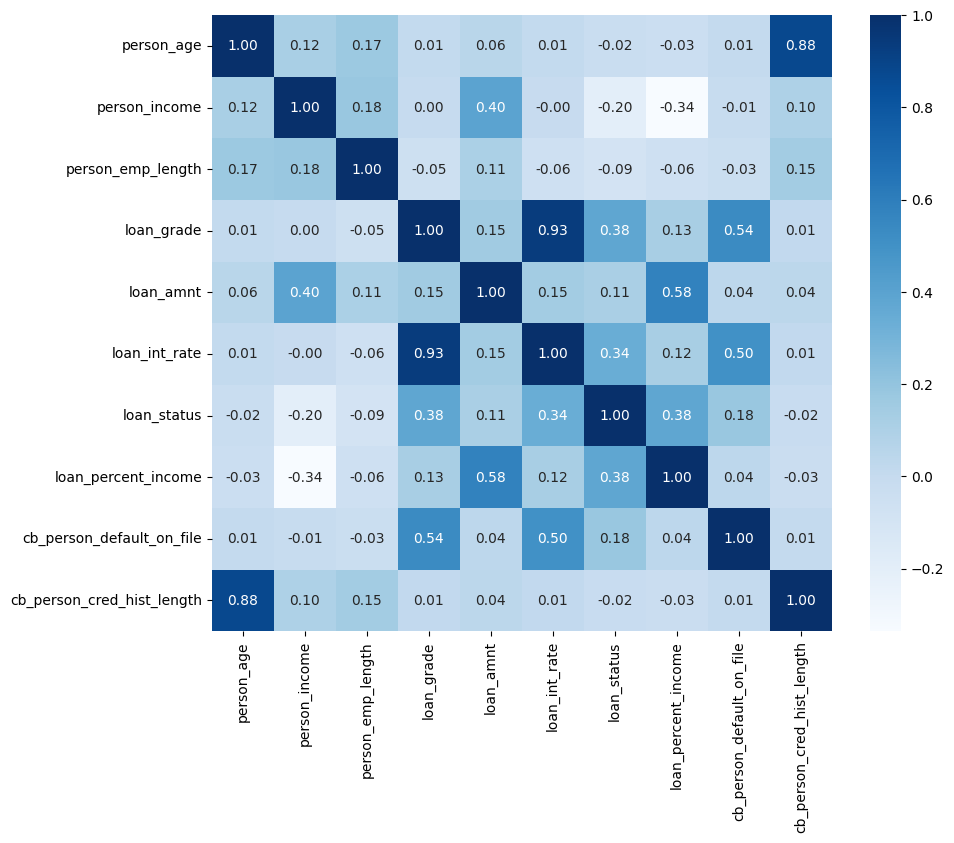

In [138]:
## Doing correlation matrix
plt.figure(figsize=(10,8))
cor_matrix = df.corr(numeric_only=True)
sns.heatmap(cor_matrix, cmap="Blues", annot=True, fmt=".2f")
plt.show

In [139]:
x = df.drop([
    "loan_status"
], axis=1)
y = df["loan_status"]


In [140]:
x_train, x_temp, y_train, y_temp = train_test_split(x,y, test_size=0.3, random_state=42)

In [141]:
x_val, x_test, y_val, y_test = train_test_split(x_temp,y_temp, test_size = 0.5, random_state=42)


In [142]:
model_logistic = LogisticRegression().fit(x_train,y_train)
model_xg = XGBRFClassifier().fit(x_train,y_train)
model_rand = RandomForestClassifier().fit(x_train,y_train)


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [143]:
y_val_log_model_predict =model_logistic.predict(x_val)
y_val_model_xg_predict = model_xg.predict(x_val)  
y_val_model_rand_predict= model_rand.predict(x_val)
 

In [144]:
print("Result for accuracy validation data")
print(" ")
print("Logistic regression", accuracy_score(y_val, y_val_log_model_predict))
print("RFC", accuracy_score(y_val, y_val_model_rand_predict))
print("XGBRFClassifier", accuracy_score(y_val, y_val_model_xg_predict))

Result for accuracy validation data
 
Logistic regression 0.8261073353644246
RFC 0.8781345207405672
XGBRFClassifier 0.8711038200140614


In [145]:
print("Result for confusion matrix validation data")
print(" ")
print("Logistic regression", confusion_matrix(y_val, y_val_log_model_predict))
print("RFC", confusion_matrix(y_val, y_val_model_rand_predict))
print("XGBRFClassifier", confusion_matrix(y_val, y_val_model_xg_predict))

Result for confusion matrix validation data
 
Logistic regression [[3161  156]
 [ 586  364]]
RFC [[3132  185]
 [ 335  615]]
XGBRFClassifier [[3060  257]
 [ 293  657]]


## Lets do for the test data

In [146]:
y_test_log_model_predict =model_logistic.predict(x_test)
y_test_model_xg_predict = model_xg.predict(x_test)  
y_test_model_rand_predict= model_rand.predict(x_test)
 

In [147]:
print("Result for accuracy test data")
print(" ")
print("Logistic regression", accuracy_score(y_test, y_test_log_model_predict))
print("RFC", accuracy_score(y_test, y_test_model_xg_predict))
print("XGBRFClassifier", accuracy_score(y_test, y_test_model_rand_predict))

Result for accuracy test data
 
Logistic regression 0.8275538894095595
RFC 0.8795688847235239
XGBRFClassifier 0.887535145267104


In [148]:
print("Result for confusion matrix train data")
print(" ")
print("Logistic regression", confusion_matrix(y_val, y_val_log_model_predict))
print("RFC", confusion_matrix(y_val, y_val_model_rand_predict))
print("XGBRFClassifier", confusion_matrix(y_val, y_val_model_xg_predict))

Result for confusion matrix train data
 
Logistic regression [[3161  156]
 [ 586  364]]
RFC [[3132  185]
 [ 335  615]]
XGBRFClassifier [[3060  257]
 [ 293  657]]


XGBoost achieves the highest accuracy, while Random Forest provides more consistent and balanced performance. Logistic Regression performs хуже compared to the ensemble models.